# Partie A — Audit des données & Compréhension métier

**Objectif** : Analyser le dataset avec un regard critique avant toute modélisation.  
Identifier les variables utiles, les biais, les limites et les opportunités.

In [ ]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# ── Chargement des données ────────────────────────────────
df = pd.read_csv('../data/raw/marketing_campaign.csv', sep=';')

print(f" Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé : 2240 lignes × 29 colonnes


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
# ── 1. VUE GÉNÉRALE ──────────────────────────────────────
print("=" * 60)
print("1. STRUCTURE DU DATASET")
print("=" * 60)
print(df.info())

1. STRUCTURE DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240

In [ ]:
# ── 2. VALEURS MANQUANTES ────────────────────────────────
print("=" * 60)
print("2. VALEURS MANQUANTES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    '% Manquants': missing_pct
}).query('Manquants > 0')

print(missing_df if len(missing_df) > 0 else " Aucune valeur manquante détectée")

2. VALEURS MANQUANTES
        Manquants  % Manquants
Income         24         1.07


In [5]:
# ── 3. STATISTIQUES DESCRIPTIVES ─────────────────────────
print("=" * 60)
print("3. STATISTIQUES DESCRIPTIVES")
print("=" * 60)
df.describe()

3. STATISTIQUES DESCRIPTIVES


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,5592.16,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,44.02,2.33,4.08,2.66,5.79,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.00,11.00,0.15
std,3246.66,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,52.17,1.93,2.78,2.92,3.25,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.00,0.00,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
25%,2828.25,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,24.00,2.00,4.00,2.00,5.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
75%,8427.75,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,56.00,3.00,6.00,4.00,8.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,11.00,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,362.00,15.00,27.00,28.00,13.00,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,11.00,1.00


4. VARIABLE CIBLE : Response
Réponse NON (0) : 1906 clients (85.1%)
Réponse OUI (1) : 334 clients (14.9%)

  Ratio déséquilibre : 1 pour 5


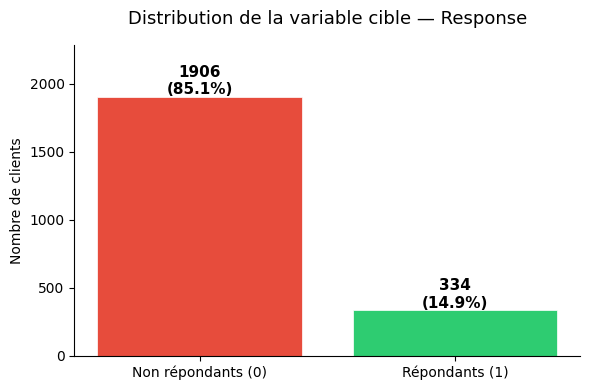

 Figure sauvegardée


In [7]:
# ── 4. VARIABLE CIBLE - ÉQUILIBRE DES CLASSES ────────────
print("=" * 60)
print("4. VARIABLE CIBLE : Response")
print("=" * 60)
target_counts = df['Response'].value_counts()
target_pct = df['Response'].value_counts(normalize=True) * 100

print(f"Réponse NON (0) : {target_counts[0]} clients ({target_pct[0]:.1f}%)")
print(f"Réponse OUI (1) : {target_counts[1]} clients ({target_pct[1]:.1f}%)")
print(f"\n  Ratio déséquilibre : 1 pour {target_counts[0]//target_counts[1]}")

# Visualisation
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non répondants (0)', 'Répondants (1)'],
              target_counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=0.5)
for bar, val, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribution de la variable cible — Response', fontsize=13, pad=15)
ax.set_ylabel('Nombre de clients')
ax.set_ylim(0, max(target_counts.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('../reports/figures/A_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

In [8]:
# ── 5. VARIABLES CONSTANTES & ANOMALIES ──────────────────
print("=" * 60)
print("5. VARIABLES CONSTANTES (à supprimer)")
print("=" * 60)
constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Variables constantes : {constantes}")

print("\n" + "=" * 60)
print("6. VALEURS ABERRANTES — Income & Year_Birth")
print("=" * 60)
print(f"Income max    : {df['Income'].max():,.0f}")
print(f"Income median : {df['Income'].median():,.0f}")
print(f"\nYear_Birth min : {df['Year_Birth'].min()} → âge implicite : {2024 - df['Year_Birth'].min()} ans")
print(f"Year_Birth max : {df['Year_Birth'].max()} → âge implicite : {2024 - df['Year_Birth'].max()} ans")

print("\n" + "=" * 60)
print("7. TYPES DE VARIABLES")
print("=" * 60)
print(f"Numériques  : {df.select_dtypes(include='number').shape[1]} variables")
print(f"Catégorielles : {df.select_dtypes(include='object').shape[1]} variables")
print(f"\nCatégorielles : {list(df.select_dtypes(include='object').columns)}")
print(f"\nModalités Marital_Status : {df['Marital_Status'].unique()}")
print(f"Modalités Education      : {df['Education'].unique()}")

5. VARIABLES CONSTANTES (à supprimer)
Variables constantes : ['Z_CostContact', 'Z_Revenue']

6. VALEURS ABERRANTES — Income & Year_Birth
Income max    : 666,666
Income median : 51,382

Year_Birth min : 1893 → âge implicite : 131 ans
Year_Birth max : 1996 → âge implicite : 28 ans

7. TYPES DE VARIABLES
Numériques  : 26 variables
Catégorielles : 3 variables

Catégorielles : ['Education', 'Marital_Status', 'Dt_Customer']

Modalités Marital_Status : <StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str
Modalités Education      : <StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str


In [9]:
# ── 8. SYNTHÈSE AUDIT ────────────────────────────────────
print("=" * 60)
print("8. SYNTHESE CRITIQUE — AUDIT PARTIE A")
print("=" * 60)

audit = {
    "POINTS POSITIFS": [
        "Dataset complet : 2240 clients x 29 variables",
        "Variable cible Response bien définie (binaire)",
        "Richesse des variables : socio-démo + comportement + campagnes",
        "Une seule variable avec manquants (Income, 1.07%)",
    ],
    "POINTS A CORRIGER": [
        "Income : 24 valeurs manquantes + 1 outlier (666 666)",
        "Year_Birth : 3 valeurs aberrantes (nés avant 1930)",
        "Marital_Status : modalités parasites (Absurd, YOLO, Alone)",
        "Z_CostContact & Z_Revenue : constantes, zéro information",
        "Dt_Customer : date brute -> à convertir en ancienneté (jours)",
    ],
    "RISQUES BUSINESS": [
        "Déséquilibre cible : 85% vs 15% -> risque biais modèle",
        "Dataset limité (2240 obs) -> risque surapprentissage",
        "Pas de variable géographique -> segmentation incomplète",
        "Pas d'historique temporel -> pas de tendance détectable",
    ],
    "VARIABLES CLES IDENTIFIEES": [
        "Income -> principal driver de dépenses",
        "MntWines, MntMeatProducts -> dépenses dominantes",
        "AcceptedCmp1-5 -> historique réponses campagnes",
        "Recency -> signal d'engagement récent",
        "NumStorePurchases, NumWebPurchases -> canal préféré",
    ]
}

for section, points in audit.items():
    print(f"\n{section}")
    for p in points:
        print(f"   - {p}")

print("\n" + "=" * 60)
print("NEXT : Partie B — Préparation & Feature Engineering")
print("=" * 60)

8. SYNTHESE CRITIQUE — AUDIT PARTIE A

POINTS POSITIFS
   - Dataset complet : 2240 clients x 29 variables
   - Variable cible Response bien définie (binaire)
   - Richesse des variables : socio-démo + comportement + campagnes
   - Une seule variable avec manquants (Income, 1.07%)

POINTS A CORRIGER
   - Income : 24 valeurs manquantes + 1 outlier (666 666)
   - Year_Birth : 3 valeurs aberrantes (nés avant 1930)
   - Marital_Status : modalités parasites (Absurd, YOLO, Alone)
   - Z_CostContact & Z_Revenue : constantes, zéro information
   - Dt_Customer : date brute -> à convertir en ancienneté (jours)

RISQUES BUSINESS
   - Déséquilibre cible : 85% vs 15% -> risque biais modèle
   - Dataset limité (2240 obs) -> risque surapprentissage
   - Pas de variable géographique -> segmentation incomplète
   - Pas d'historique temporel -> pas de tendance détectable

VARIABLES CLES IDENTIFIEES
   - Income -> principal driver de dépenses
   - MntWines, MntMeatProducts -> dépenses dominantes
   - Acce